# Demo 02: Live RAG Search

This notebook is for live Google File Search RAG demos over the whisky catalogue.

It uses existing File Search stores, but sends the **user query live** during the demo.

- Section 1: text query -> product text RAG store vs product image RAG store vs product multimodal RAG store
- Section 2: image query -> product image RAG store vs product multimodal RAG store

Paste API keys in the notebook cells. This notebook does not read `.env`.

In [11]:
from __future__ import annotations

import base64
import html
import json
import sys
import time
from getpass import getpass
from pathlib import Path
from typing import Any

from IPython.display import HTML, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from rs_demo.rag import GeminiFileSearchClient, load_store_name  # noqa: E402

PRODUCT_PATH = ROOT / "data/extracted/product_parse_sample.jsonl"
TEXT_STORE_MANIFEST = ROOT / "data/rag/rag_product_text_store.json"
IMAGE_STORE_MANIFEST = ROOT / "data/rag/rag_product_image_store.json"
MULTIMODAL_STORE_MANIFEST = ROOT / "data/rag/rag_product_multimodal_store.json"

TOP_K = 5
GENERATION_MODEL = "gemini-3.1-flash-lite"
SLEEP_BETWEEN_CALLS = 5.0

ROOT

PosixPath('/Users/eltonli/code/rs-demo')

## Load Catalogue and Store References

This only reads local product metadata and local store manifests. It does not call the API.

In [12]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def load_store_manifest(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


products = load_jsonl(PRODUCT_PATH)
products_by_id = {record["product_id"]: record for record in products}

text_store_manifest = load_store_manifest(TEXT_STORE_MANIFEST)
image_store_manifest = load_store_manifest(IMAGE_STORE_MANIFEST)
multimodal_store_manifest = load_store_manifest(MULTIMODAL_STORE_MANIFEST)

text_store_name = load_store_name(TEXT_STORE_MANIFEST)
image_store_name = load_store_name(IMAGE_STORE_MANIFEST)
multimodal_store_name = load_store_name(MULTIMODAL_STORE_MANIFEST)

print("products:", len(products))
print("text RAG store:", text_store_name)
print("image RAG store:", image_store_name)
print("multimodal RAG store:", multimodal_store_name)

products: 533
text RAG store: fileSearchStores/ragproducttextstore-tc02qz6qfvei
image RAG store: fileSearchStores/ragproductimagestore-dppy5hhkl8n5
multimodal RAG store: fileSearchStores/ragproductmultimodalstore-fdfd4rlokjnp


## API Keys

Run this once. Paste the API key that owns each File Search store. If one key owns multiple stores, paste the same key again.

In [ ]:
def prompt_api_key(label: str) -> str:
    key = getpass(f"Paste Google API key for {label}: ").strip()
    if not key:
        raise ValueError(f"Google API key is required for {label}.")
    return key


text_rag_api_key = "xxxxx"
image_rag_api_key = "xxxxx"
multimodal_rag_api_key = "xxxxx"

text_rag_client = GeminiFileSearchClient(api_key=text_rag_api_key)
image_rag_client = GeminiFileSearchClient(api_key=image_rag_api_key)
multimodal_rag_client = GeminiFileSearchClient(api_key=multimodal_rag_api_key)

print("RAG clients ready.")

RAG clients ready.


## Display Helpers

In [14]:
def html_escape(value: Any) -> str:
    if value is None:
        return ""
    return html.escape(str(value))


def resolve_path(value: str | Path) -> Path:
    path = Path(value).expanduser()
    if not path.is_absolute():
        path = ROOT / path
    return path


def image_data_uri(path: str | Path | None) -> str:
    if not path:
        return ""
    resolved = resolve_path(path)
    if not resolved.exists():
        return ""
    suffix = resolved.suffix.lower()
    mime_type = {
        ".jpg": "image/jpeg",
        ".jpeg": "image/jpeg",
        ".png": "image/png",
        ".webp": "image/webp",
    }.get(suffix, "image/png")
    data = base64.b64encode(resolved.read_bytes()).decode("ascii")
    return f"data:{mime_type};base64,{data}"


def image_tag(path: str | Path | None, width: int = 120) -> str:
    uri = image_data_uri(path)
    if not uri:
        return ""
    return f'<img src="{uri}" style="max-width:{width}px; max-height:{width}px; object-fit:contain;" />'


def product_image_path(product_id: str) -> str | None:
    record = products_by_id.get(product_id, {})
    return record.get("cropped_product_image_path") or record.get("product_image_path")


def product_display_name(product_id: str, fallback: str = "") -> str:
    record = products_by_id.get(product_id, {})
    return str(record.get("name") or fallback or product_id)


def run_rag_query(
    *,
    client: GeminiFileSearchClient,
    store_name: str,
    query_id: str,
    query: str,
    query_type: str,
    image_path: Path | None = None,
):
    return client.search_products(
        store_name=store_name,
        query_id=query_id,
        query=query,
        query_type=query_type,
        image_path=str(image_path) if image_path else None,
        top_k=TOP_K,
        model_name=GENERATION_MODEL,
    )


def rag_result_table_html(title: str, result) -> str:
    rows = []
    for item in result.ranked_products[:TOP_K]:
        product_id = item.product_id
        record = products_by_id.get(product_id, {})
        rows.append(
            f"""
            <tr>
              <td style="text-align:center; font-weight:600;">{item.rank}</td>
              <td>{image_tag(product_image_path(product_id), width=92)}</td>
              <td>
                <div><code>{html_escape(product_id)}</code></div>
                <div style="font-weight:600;">{html_escape(product_display_name(product_id, item.product_name))}</div>
                <div style="font-size:12px; color:#555;">{html_escape(record.get('brand_or_distillery'))}</div>
              </td>
              <td>{html_escape(item.reason)}</td>
            </tr>
            """
        )
    if not rows:
        rows.append(
            """
            <tr>
              <td colspan="4" style="color:#9b1c1c;">No parseable product IDs returned. Check the raw model text below.</td>
            </tr>
            """
        )
    raw_text = html_escape(result.raw_text)
    return f"""
    <div style="border:1px solid #ddd; padding:12px; border-radius:6px;">
      <h3 style="margin:0 0 8px 0;">{html_escape(title)}</h3>
      <table style="width:100%; border-collapse:collapse; font-size:13px;">
        <thead>
          <tr style="border-bottom:1px solid #ddd; text-align:left;">
            <th style="width:42px;">Rank</th>
            <th style="width:104px;">Image</th>
            <th style="width:210px;">Product</th>
            <th>Reason</th>
          </tr>
        </thead>
        <tbody>{''.join(rows)}</tbody>
      </table>
      <details style="margin-top:10px;"><summary>Raw model response</summary><pre style="white-space:pre-wrap; font-size:12px;">{raw_text}</pre></details>
    </div>
    """


def display_rag_comparison(
    *,
    heading: str,
    query_text: str,
    left_title: str,
    left_result,
    right_title: str,
    right_result,
    middle_title: str | None = None,
    middle_result = None,
    query_image_path: Path | None = None,
) -> None:
    query_image_html = ""
    if query_image_path is not None:
        query_image_html = f"<div style='margin:8px 0 14px 0;'>{image_tag(query_image_path, width=220)}</div>"
    result_tables = [rag_result_table_html(left_title, left_result)]
    if middle_title is not None and middle_result is not None:
        result_tables.append(rag_result_table_html(middle_title, middle_result))
    result_tables.append(rag_result_table_html(right_title, right_result))

    html_text = f"""
    <div style="font-family:-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;">
      <h2>{html_escape(heading)}</h2>
      <p><b>Query:</b> {html_escape(query_text)}</p>
      {query_image_html}
      <div style="display:grid; grid-template-columns:repeat(auto-fit, minmax(300px, 1fr)); gap:16px; align-items:start;">
        {''.join(result_tables)}
      </div>
    </div>
    """
    display(HTML(html_text))

## Section 1: Live Text Query

Type a text query during the demo. The notebook sends the same query to the text, image, and multimodal RAG stores.


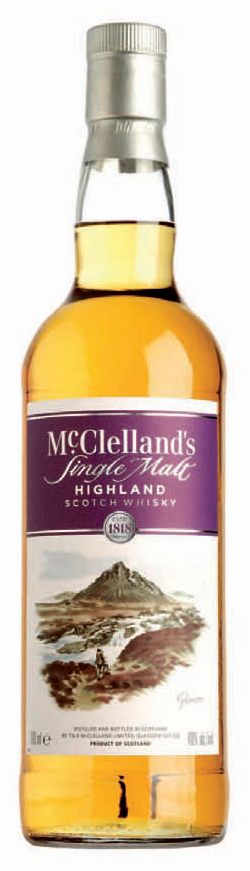
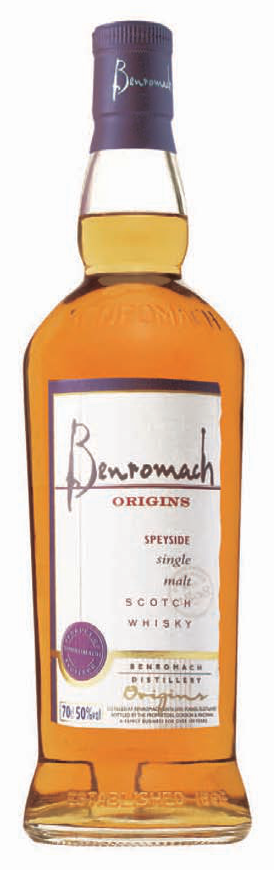
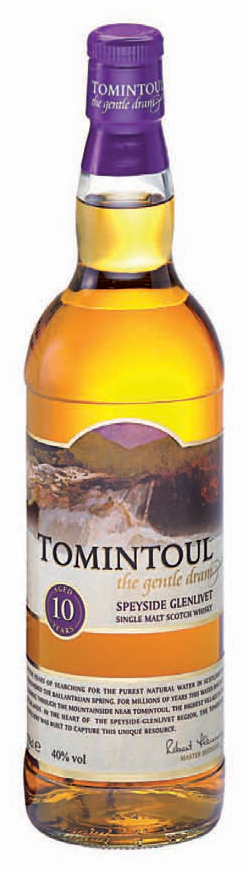
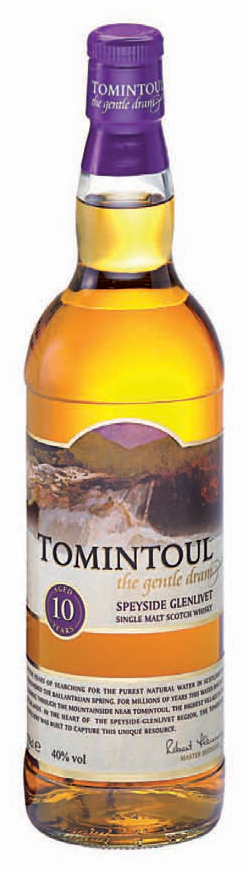
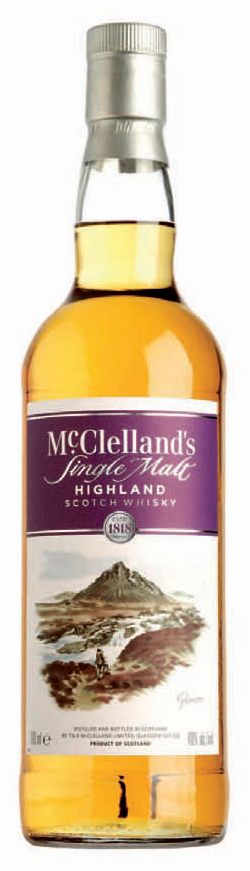
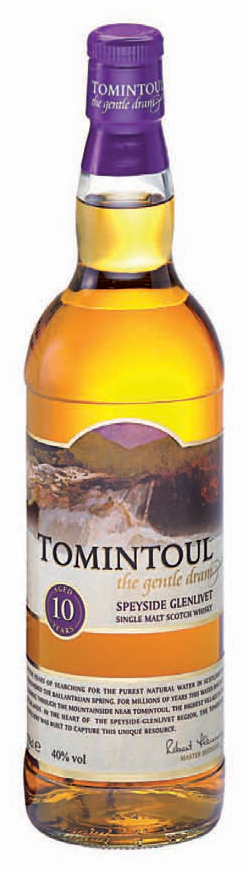
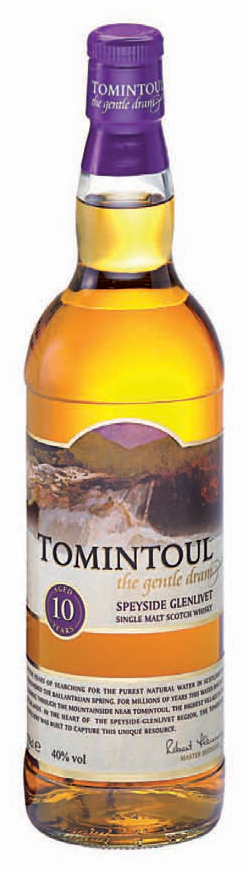
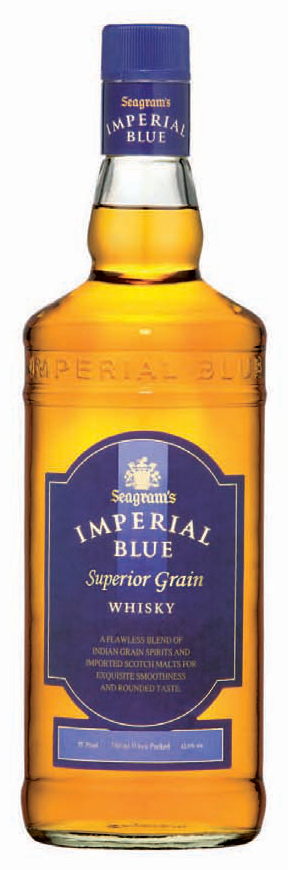
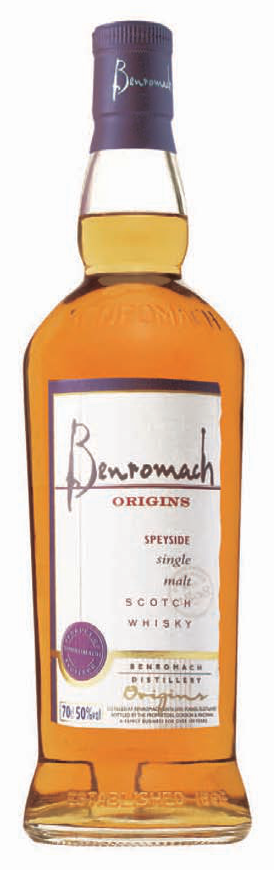
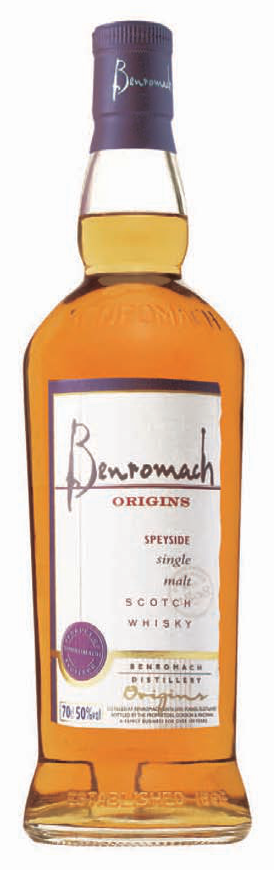

In [15]:
TEXT_QUERY = "I want a purple bottled whisky"
if not TEXT_QUERY:
    raise ValueError("Text query must not be empty.")

text_store_result = run_rag_query(
    client=text_rag_client,
    store_name=text_store_name,
    query_id="live_text_query_to_text_rag",
    query=TEXT_QUERY,
    query_type="text",
)

time.sleep(SLEEP_BETWEEN_CALLS)

image_store_text_result = run_rag_query(
    client=image_rag_client,
    store_name=image_store_name,
    query_id="live_text_query_to_image_rag",
    query=TEXT_QUERY,
    query_type="text",
)

time.sleep(SLEEP_BETWEEN_CALLS)

multimodal_store_text_result = run_rag_query(
    client=multimodal_rag_client,
    store_name=multimodal_store_name,
    query_id="live_text_query_to_multimodal_rag",
    query=TEXT_QUERY,
    query_type="text",
)

display_rag_comparison(
    heading="Text Query RAG Comparison",
    query_text=TEXT_QUERY,
    left_title="Text query -> product text RAG store",
    left_result=text_store_result,
    middle_title="Text query -> product image RAG store",
    middle_result=image_store_text_result,
    right_title="Text query -> product multimodal RAG store",
    right_result=multimodal_store_text_result,
)

## Section 2: Live Image Query

Type a local image path during the demo. The notebook sends the image with a fixed identification prompt to the image RAG store and the multimodal RAG store.

Example path:

`data/eval/movie_scene_bottle_crops/msq004-john-wick-blantons.crop.jpg`

In [ ]:
IMAGE_QUERY_PATH = input("Enter a local image path: ").strip()
resolved_image_path = resolve_path(IMAGE_QUERY_PATH)
if not resolved_image_path.exists():
    raise FileNotFoundError(resolved_image_path)

IMAGE_QUERY_TEXT = "Find the catalogue whisky product that matches the attached image."

image_store_result = run_rag_query(
    client=image_rag_client,
    store_name=image_store_name,
    query_id="live_image_query_to_image_rag",
    query=IMAGE_QUERY_TEXT,
    query_type="image",
    image_path=resolved_image_path,
)

time.sleep(SLEEP_BETWEEN_CALLS)

multimodal_store_image_result = run_rag_query(
    client=multimodal_rag_client,
    store_name=multimodal_store_name,
    query_id="live_image_query_to_multimodal_rag",
    query=IMAGE_QUERY_TEXT,
    query_type="image",
    image_path=resolved_image_path,
)

display_rag_comparison(
    heading="Image Query RAG Comparison",
    query_text=IMAGE_QUERY_TEXT,
    query_image_path=resolved_image_path,
    left_title="Image query -> product image RAG store",
    left_result=image_store_result,
    right_title="Image query -> product multimodal RAG store",
    right_result=multimodal_store_image_result,
)

## Optional Re-display

After running a query section once, you can re-run only the display call with a different layout or top-k setting without calling the API again.

In [ ]:
# Example after Section 1 has run:
# display_rag_comparison(
#     heading="Text Query RAG Comparison",
#     query_text=TEXT_QUERY,
#     left_title="Text query -> product text RAG store",
#     left_result=text_store_result,
#     middle_title="Text query -> product image RAG store",
#     middle_result=image_store_text_result,
#     right_title="Text query -> product multimodal RAG store",
#     right_result=multimodal_store_text_result,
# )